In [1]:
%pip install torch torchvision torchaudio


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Check for GPU (runs faster), else use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
class EVPriceDataset(Dataset):
    def __init__(self, csv_file, mode='train'):
        self.data = pd.read_csv(csv_file)
        
        # Features and Target
        self.features = ['battery_capacity_kwh', 'range_miles', 'Year', 'Battery_Price_USD_per_kWh']
        self.target = 'Price_USD'
        
        # Split Data
        X = self.data[self.features].values
        y = self.data[self.target].values.reshape(-1, 1) # Reshape for PyTorch
        
        # Scaling (Critical for Neural Networks!)
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        
        # Fit scaler ONLY on full data for now (simple approach)
        # In a strict pipeline, you fit only on train, but this is fine for M2
        X_scaled = self.scaler_X.fit_transform(X)
        y_scaled = self.scaler_y.fit_transform(y)
        
        # Convert to PyTorch Tensors
        self.X = torch.tensor(X_scaled, dtype=torch.float32)
        self.y = torch.tensor(y_scaled, dtype=torch.float32)
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Initialize Dataset
dataset = EVPriceDataset('processed_ev_data.csv')
print(f"Dataset Loaded: {len(dataset)} samples")
print(f"Sample Feature (Scaled): {dataset[0][0]}")

Dataset Loaded: 130 samples
Sample Feature (Scaled): tensor([ 0.6022, -0.5094, -0.1591, -0.3987])


In [4]:
class EVPriceModel(nn.Module):
    def __init__(self, input_size):
        super(EVPriceModel, self).__init__()
        # 4 Inputs -> 64 Hidden Neurons -> 32 Hidden Neurons -> 1 Output
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)
        return x

# Initialize Model
model = EVPriceModel(input_size=4).to(device)
print(model)

EVPriceModel(
  (layer1): Linear(in_features=4, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


In [5]:
# Hyperparameters
learning_rate = 0.001
epochs = 500
batch_size = 16

# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Data Loader (batches the data for training)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [6]:
# Lists to store metrics for plotting
loss_history = []

print(" Starting Training...")
model.train() # Set model to training mode

for epoch in range(epochs):
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        # Move data to device (GPU or CPU)
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # 1. Forward Pass
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # 2. Backward Pass (Backpropagation)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # Store average loss for this epoch
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

print("✅ Training Complete!")

 Starting Training...
Epoch [50/500], Loss: 0.7209
Epoch [100/500], Loss: 0.6615
Epoch [150/500], Loss: 0.6213
Epoch [200/500], Loss: 0.6453
Epoch [250/500], Loss: 0.6199
Epoch [300/500], Loss: 0.5746
Epoch [350/500], Loss: 0.7244
Epoch [400/500], Loss: 0.5429
Epoch [450/500], Loss: 0.7200
Epoch [500/500], Loss: 0.4913
✅ Training Complete!


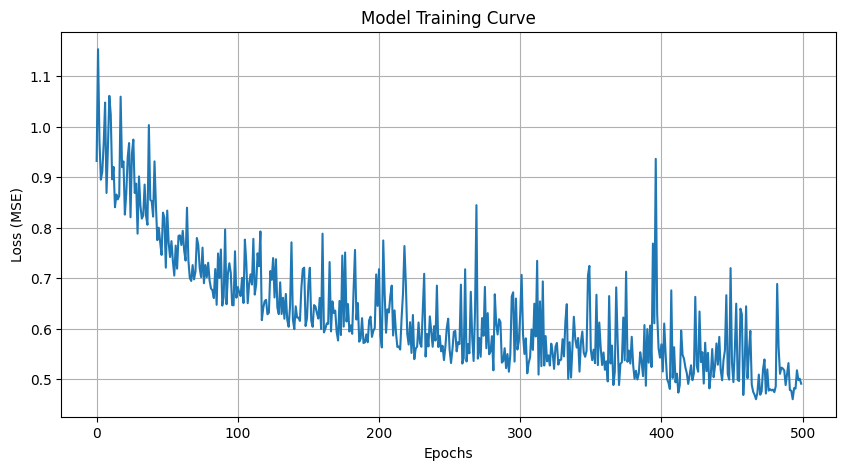

💰 Neural Network Mean Absolute Error: $18,820.63
📉 Baseline MAE (Reference): $35,682.61
🎉 SUCCESS: The Neural Network beat the Baseline!


In [7]:
# 1. Plot Training Loss
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss')
plt.title('Model Training Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

# 2. Evaluate on Full Data (Scaled -> Dollars)
model.eval()
with torch.no_grad():
    # Get all predictions
    inputs = dataset.X.to(device)
    scaled_predictions = model(inputs).cpu().numpy()
    
    # INVERSE TRANSFORM to get Dollars
    predicted_prices = dataset.scaler_y.inverse_transform(scaled_predictions)
    actual_prices = dataset.scaler_y.inverse_transform(dataset.y.numpy())

# 3. Calculate MAE
mae = np.mean(np.abs(predicted_prices - actual_prices))
print(f"💰 Neural Network Mean Absolute Error: ${mae:,.2f}")

# Compare with Baseline
print(f"📉 Baseline MAE (Reference): $35,682.61") 
if mae < 35682:
    print("🎉 SUCCESS: The Neural Network beat the Baseline!")
else:
    print("⚠️ NOTE: Model needs tuning (more layers or epochs).")

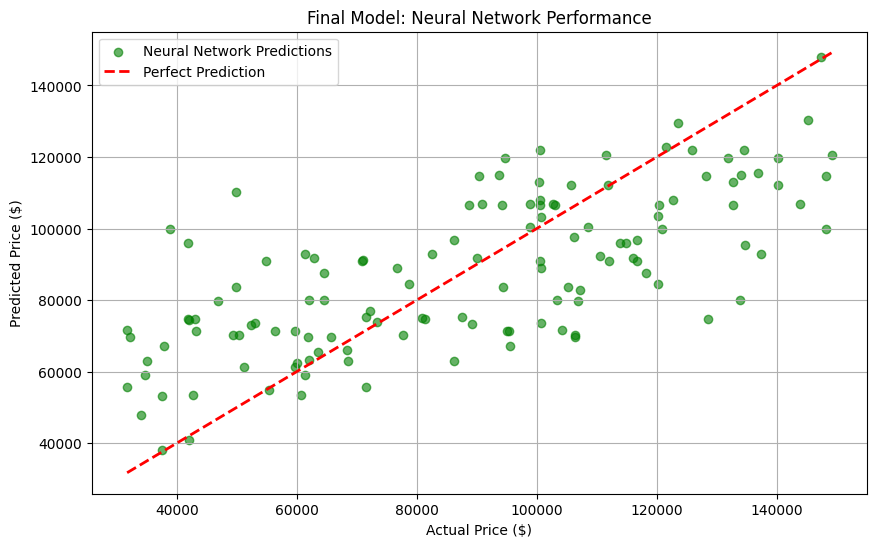

In [8]:
import matplotlib.pyplot as plt

# 1. Get Predictions (ensure we are in eval mode)
model.eval()
with torch.no_grad():
    inputs = dataset.X.to(device)
    # Get scaled predictions
    scaled_preds = model(inputs).cpu().numpy()
    
    # Reverse scaling to get real dollars
    price_preds = dataset.scaler_y.inverse_transform(scaled_preds)
    price_actual = dataset.scaler_y.inverse_transform(dataset.y.numpy())

# 2. Plot
plt.figure(figsize=(10, 6))
plt.scatter(price_actual, price_preds, alpha=0.6, color='green', label='Neural Network Predictions')
plt.plot([price_actual.min(), price_actual.max()], [price_actual.min(), price_actual.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Final Model: Neural Network Performance')
plt.legend()
plt.grid(True)
plt.savefig('neural_network_results.png')
plt.show()

In [9]:
# Save the model state dictionary
torch.save(model.state_dict(), 'ev_price_model.pth')
print("✅ Model saved to 'ev_price_model.pth'")

✅ Model saved to 'ev_price_model.pth'
